In [1]:
import os 
import numpy as np
import torch 
import matplotlib.pyplot as plt
import pandas as pd

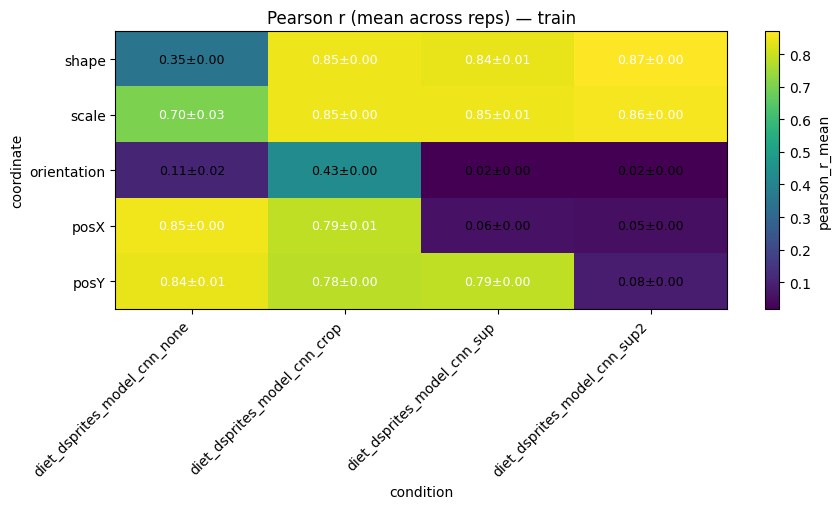

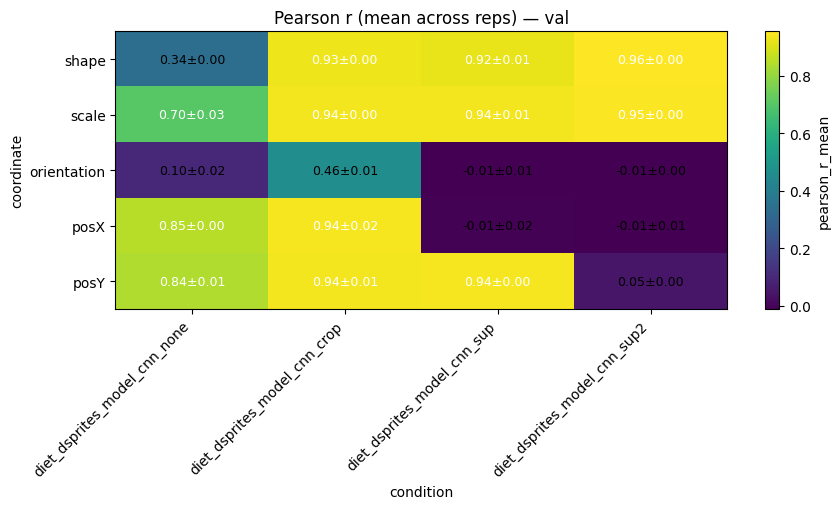

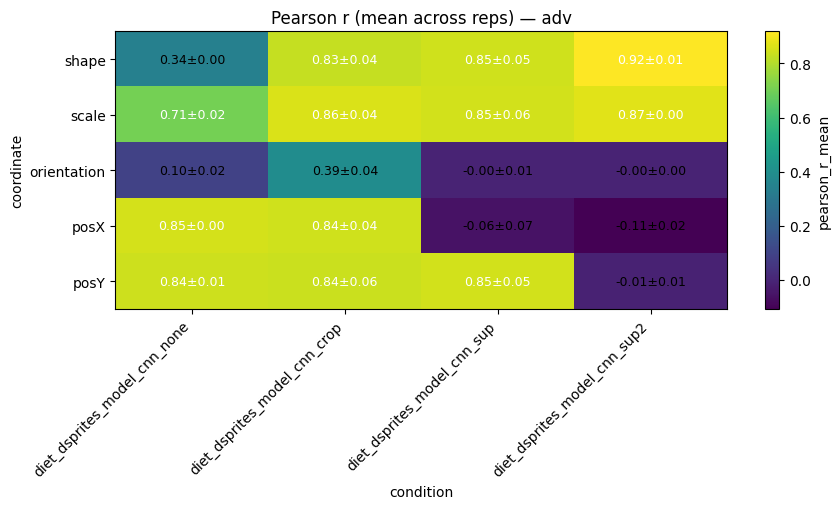

In [3]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------- sv sv
# Config
# -----------------------------
ds = "dsprites"  # dataset tag used in filenames / condition names

ROOT = Path(".")  # change if needed
GLOB_PATTERN = f"**/logs_pgd/*{ds}*/identifiability.txt"

ANNOTATE_STYLE = "mean±std"  # "mean" or "mean±std"
TEXT_DECIMALS = 2

# Put the exact condition order you want here (left-to-right in the heatmap)
CONDITION_ORDER = [
    f"diet_{ds}_model_cnn_none",
    f"diet_{ds}_model_cnn_crop",
    f"diet_{ds}_model_cnn_sup",
    f"diet_{ds}_model_cnn_sup2",
    #f"diet_{ds}_model_cnn_simclr2",
]

# If True: keep ONLY conditions in CONDITION_ORDER (intersection)
# If False: show all conditions, but sort by (CONDITION_ORDER first, then remaining alphabetically)
ONLY_USE_CONDITION_ORDER = True

# -----------------------------
# Regex parsers (match your log format)
# -----------------------------
COORD_RE = re.compile(r"^Coordinate\s+(\d+)\s+(.+?)\s*$")
SPLIT_RE = re.compile(
    r"^(train|val|adv)\s+PearsonRResult\("
    r"statistic=np\.float64\(([-+0-9.eE]+)\),\s*"
    r"pvalue=np\.float64\(([-+0-9.eE]+)\)\)"
)
REP_RE = re.compile(r"^(?P<condition>.+?)_rep_(?P<rep>\d+)$")


def parse_identifiability_file(path: Path) -> list[dict]:
    rows: list[dict] = []
    current_coord_idx = None
    current_coord_name = None

    experiment = path.parent.name  # folder name holding identifiability.txt

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            m_coord = COORD_RE.match(line)
            if m_coord:
                current_coord_idx = int(m_coord.group(1))
                current_coord_name = m_coord.group(2).strip()
                continue

            m_split = SPLIT_RE.match(line)
            if m_split and current_coord_idx is not None:
                split = m_split.group(1)
                statistic = float(m_split.group(2))
                pvalue = float(m_split.group(3))
                rows.append(
                    dict(
                        experiment=experiment,
                        file=str(path),
                        coordinate_idx=current_coord_idx,
                        coordinate=current_coord_name,
                        split=split,
                        pearson_r=statistic,
                        pvalue=pvalue,
                    )
                )

    return rows


def parse_all(root: Path, pattern: str) -> pd.DataFrame:
    files = sorted(root.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files found under {root} matching: {pattern}")

    all_rows: list[dict] = []
    for p in files:
        all_rows.extend(parse_identifiability_file(p))

    df = pd.DataFrame(all_rows)
    if df.empty:
        raise ValueError("Parsed zero rows. Check regexes vs your log format.")
    return df


def add_condition_and_rep(df: pd.DataFrame) -> pd.DataFrame:
    m = df["experiment"].str.extract(REP_RE)
    out = df.copy()
    out["condition"] = m["condition"].fillna(out["experiment"])
    out["rep"] = pd.to_numeric(m["rep"], errors="coerce")
    return out


def aggregate_across_reps(df: pd.DataFrame) -> pd.DataFrame:
    agg = (
        df.groupby(["condition", "split", "coordinate_idx", "coordinate"], as_index=False)
        .agg(
            pearson_r_mean=("pearson_r", "mean"),
            pearson_r_std=("pearson_r", "std"),
            n=("pearson_r", "count"),
        )
    )
    # std is NaN when n=1
    agg["pearson_r_std"] = agg["pearson_r_std"].fillna(0.0)
    return agg


# -----------------------------
# Plotting helpers
# -----------------------------
def _coord_order(agg: pd.DataFrame) -> list[str]:
    return (
        agg[["coordinate_idx", "coordinate"]]
        .drop_duplicates()
        .sort_values("coordinate_idx")["coordinate"]
        .tolist()
    )


def _condition_order(existing_cols: list[str]) -> list[str]:
    """
    Build the condition order to apply to the pivot columns.
    """
    if ONLY_USE_CONDITION_ORDER:
        # Only show the ones you listed, in that order, that actually exist
        return [c for c in CONDITION_ORDER if c in existing_cols]

    # Otherwise: conditions in your list first, then the rest alphabetically
    listed = [c for c in CONDITION_ORDER if c in existing_cols]
    remaining = sorted([c for c in existing_cols if c not in set(listed)])
    return listed + remaining


def plot_heatmap_annotated(
    agg: pd.DataFrame,
    split: str,
    annotate: str = "mean±std",
    decimals: int = 2,
):
    """
    Heatmap: coordinates (rows) x conditions (cols)
    Values: mean across reps for the requested split, with numeric annotations.
    """
    sub = agg[agg["split"] == split].copy()
    if sub.empty:
        raise ValueError(f"No rows for split={split}")

    # Coordinate (row) order
    coord_order = _coord_order(agg)

    mean_p = sub.pivot_table(
        index="coordinate",
        columns="condition",
        values="pearson_r_mean",
        aggfunc="mean",
    )
    std_p = sub.pivot_table(
        index="coordinate",
        columns="condition",
        values="pearson_r_std",
        aggfunc="mean",
    )

    # Enforce row order
    mean_p = mean_p.reindex(index=coord_order)
    std_p = std_p.reindex(index=coord_order)

    # Enforce column order
    desired_cols = _condition_order(list(mean_p.columns))
    mean_p = mean_p.reindex(columns=desired_cols)
    std_p = std_p.reindex(columns=desired_cols)

    if mean_p.shape[1] == 0:
        raise ValueError(
            f"No columns left after applying CONDITION_ORDER for split={split}. "
            f"Existing columns were: {list(sub['condition'].unique())}"
        )

    data = mean_p.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(max(9, 0.6 * mean_p.shape[1]), 5.2))
    im = ax.imshow(data, aspect="auto")

    ax.set_title(f"Pearson r (mean across reps) — {split}")
    ax.set_xlabel("condition")
    ax.set_ylabel("coordinate")

    ax.set_xticks(range(mean_p.shape[1]))
    ax.set_xticklabels(mean_p.columns, rotation=45, ha="right")
    ax.set_yticks(range(mean_p.shape[0]))
    ax.set_yticklabels(mean_p.index)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("pearson_r_mean")

    # Contrast heuristic for text color
    finite = data[np.isfinite(data)]
    vmin = float(np.min(finite)) if finite.size else 0.0
    vmax = float(np.max(finite)) if finite.size else 1.0
    denom = (vmax - vmin) if (vmax - vmin) != 0 else 1.0

    for i in range(mean_p.shape[0]):
        for j in range(mean_p.shape[1]):
            mean_val = mean_p.iat[i, j]
            std_val = std_p.iat[i, j]
            if pd.isna(mean_val):
                continue

            if annotate == "mean±std":
                text = f"{mean_val:.{decimals}f}±{std_val:.{decimals}f}"
            else:
                text = f"{mean_val:.{decimals}f}"

            norm = (mean_val - vmin) / denom
            color = "white" if norm > 0.60 else "black"
            ax.text(j, i, text, ha="center", va="center", fontsize=9, color=color)

    fig.tight_layout()
    plt.show()

GLOB_PATTERN = f"**/logs_2/*{ds}*/identifiability.txt"
# -----------------------------
# Run everything
# -----------------------------
df_raw = parse_all(ROOT, GLOB_PATTERN)
df_raw = add_condition_and_rep(df_raw)
agg = aggregate_across_reps(df_raw)

for sp in ["train", "val", "adv"]:
    plot_heatmap_annotated(agg, sp, annotate=ANNOTATE_STYLE, decimals=TEXT_DECIMALS)


In [6]:
# geom > sup > crop > none  : shape
experiments = np.unique(agg.condition)
print(experiments)

for experiment in experiments:
    agg_ = agg[agg.condition == experiment].copy()
    
    print(experiment, 
          np.mean(agg_[(agg_.split == 'val') & 
              ((agg_.coordinate_idx > 0)   )].iloc[:, 4]))


['diet_dsprites_model_cnn_crop' 'diet_dsprites_model_cnn_none'
 'diet_dsprites_model_cnn_sup' 'diet_dsprites_model_cnn_sup2']
diet_dsprites_model_cnn_crop 0.8199224729845437
diet_dsprites_model_cnn_none 0.6237385202925304
diet_dsprites_model_cnn_sup 0.4659948968625057
diet_dsprites_model_cnn_sup2 0.24368780752483213


In [7]:
ds = 'dsprites'
experiments = [
    f"diet_{ds}_model_cnn_none",
    f"diet_{ds}_model_cnn_crop",
    f"diet_{ds}_model_cnn_sup",
    f"diet_{ds}_model_cnn_sup2",
]


Across-experiment STD: ident: [np.float64(0.35709068389609766), np.float64(0.23898147023770527), np.float64(0.5477706286309503), np.float64(0.4718742359690188)] acc: [0.00024365505110474049, 0.0033462204551535624, 0.013012899046285392, 0.0003251128433058526] adv: [0.0011931075474043622, 0.037346506076951835, 0.05107071175464541, 0.00535582486331539] rob: 0.048894228102003084


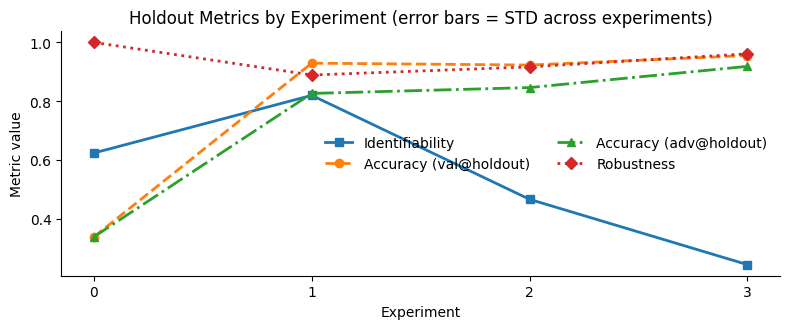

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- X axis ---
x_dict = {"dsprites": [0, 1, 2, 3]}
x = np.arange(len(experiments))

# --- Collect one point per experiment (as you already do) ---
ident, acc, adv, rob = [], [], [], []

def nanstd(vec):
    v = np.asarray(vec, dtype=float)
    v = v[~np.isnan(v)]
    if v.size <= 1:
        return np.nan
    return np.nanstd(v, ddof=1)
ident_std, acc_std, adv_std, rob_std = [], [], [], []
for experiment in experiments:
    agg_ = agg[agg.condition == experiment]
    metric_col = agg_.columns[4]
    metric_col_std = agg_.columns[5]
    id_series  = agg_.loc[(agg_.split == 'val') & (agg_.coordinate_idx != 0), metric_col]
    val_series = agg_.loc[(agg_.split == 'val') & (agg_.coordinate_idx == 0),  metric_col]
    adv_series = agg_.loc[(agg_.split == 'adv') & (agg_.coordinate_idx == 0),  metric_col]
    
    acc.append(float(agg_.loc[(agg_.split == 'val') & (agg_.coordinate_idx == 0),  metric_col].iloc[0]))
    adv.append(float(agg_.loc[(agg_.split == 'adv') & (agg_.coordinate_idx == 0),  metric_col].iloc[0]))

    acc_std.append(float(agg_.loc[(agg_.split == 'val') & (agg_.coordinate_idx == 0),  metric_col_std].iloc[0]))
    adv_std.append(float(agg_.loc[(agg_.split == 'adv') & (agg_.coordinate_idx == 0),  metric_col_std].iloc[0]))
    # Point estimates per experiment
    ident.append(id_series.mean())
    ident_std.append(id_series.std())
    # Robustness per experiment
    v = val_series.to_numpy(dtype=float)
    a = adv_series.to_numpy(dtype=float)
    n = min(len(v), len(a))
    if n == 0:
        rob.append(np.nan)
    else:
        v = v[:n]
        a = a[:n]
        v_safe = np.where(v == 0, np.nan, v)
        rob_vals = 1 - ((v - a) / v_safe)
        rob.append(np.nanmean(rob_vals))
        rob_std.append(np.nanstd(rob_vals))

# --- Compute STD across experiments (global) and apply as constant error bars ---
# ident_std = nanstd(ident)
#acc_std   = nanstd(acc)
#adv_std   = nanstd(adv)
rob_std   = nanstd(rob)

ident_yerr = np.full(len(x), ident_std, dtype=float)
acc_yerr   = np.full(len(x), acc_std,   dtype=float)
adv_yerr   = np.full(len(x), adv_std,   dtype=float)
rob_yerr   = np.full(len(x), rob_std,   dtype=float)

print("Across-experiment STD:",
      "ident:", ident_std, "acc:", acc_std, "adv:", adv_std, "rob:", rob_std)

# --- Plot: different style per series for readability ---
fig, ax = plt.subplots(figsize=(8, 3.4))

series = [
    ("Identifiability",            ident, ident_yerr, dict(fmt='s-',  linewidth=2, markersize=6)),
    ("Accuracy (val@holdout)",     acc,   acc_yerr,   dict(fmt='o--', linewidth=2, markersize=6)),
    ("Accuracy (adv@holdout)",     adv,   adv_yerr,   dict(fmt='^-.' ,linewidth=2, markersize=6)),
    ("Robustness",                 rob,   rob_yerr,   dict(fmt='D:',  linewidth=2, markersize=6)),
]

for label, y, yerr, sty in series:
    ax.errorbar(
        x, y, # yerr=yerr,
        capsize=5, capthick=1.6, elinewidth=1.6,
        label=label,
        **sty
    )

ax.set_xticks(x)
ax.set_xticklabels(x_dict[ds], rotation=0)
ax.set_xlabel("Experiment")
ax.set_ylabel("Metric value")
ax.set_title("Holdout Metrics by Experiment (error bars = STD across experiments)")
ax.legend(ncol=2, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


In [9]:
ident, ident_std

([np.float64(0.6237385202925304),
  np.float64(0.8199224729845437),
  np.float64(0.4659948968625057),
  np.float64(0.24368780752483213)],
 [np.float64(0.35709068389609766),
  np.float64(0.23898147023770527),
  np.float64(0.5477706286309503),
  np.float64(0.4718742359690188)])

In [10]:
names = ["id", "acc", "acc_adv", "rob"]
for n, x in zip(names, [ident, acc, adv, rob]):
    print(n, np.array(x).squeeze().mean(), np.array(x).squeeze().std())


id 0.538335924416103 0.21132636180337366
acc 0.7866478429628118 0.25911943301081697
acc_adv 0.7324601245067799 0.23009956384320338
rob 0.9418456149257346 0.04234364363476567


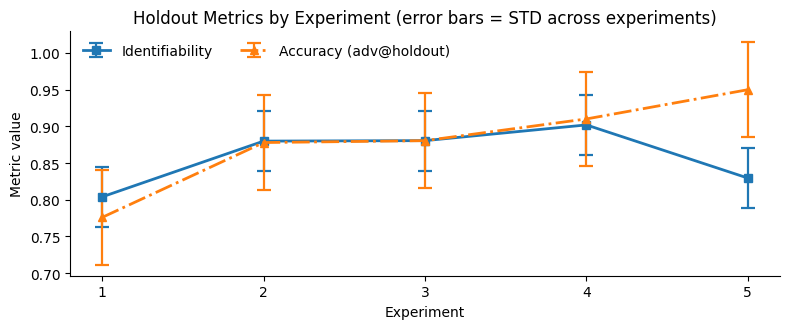

In [5]:
# --- Plot: different style per series for readability ---
fig, ax = plt.subplots(figsize=(8, 3.4))

series = [
    ("Identifiability",            ident, ident_yerr, dict(fmt='s-',  linewidth=2, markersize=6)),
    #("Accuracy (val@holdout)",     adv,   adv_yerr,   dict(fmt='o--', linewidth=2, markersize=6)),
    ("Accuracy (adv@holdout)",     acc,   acc_yerr,   dict(fmt='^-.' ,linewidth=2, markersize=6)),
    #("Robustness",                 rob,   rob_yerr,   dict(fmt='D:',  linewidth=2, markersize=6)),
]

for label, y, yerr, sty in series:
    ax.errorbar(
        x, y, yerr=yerr,
        capsize=5, capthick=1.6, elinewidth=1.6,
        label=label,
        **sty
    )

ax.set_xticks(x)
ax.set_xticklabels(x_dict[ds], rotation=0)
ax.set_xlabel("Experiment")
ax.set_ylabel("Metric value")
ax.set_title("Holdout Metrics by Experiment (error bars = STD across experiments)")
ax.legend(ncol=2, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

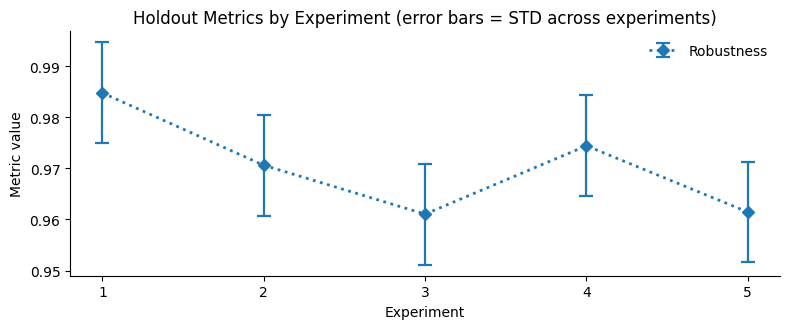

In [8]:
# --- Plot: different style per series for readability ---
fig, ax = plt.subplots(figsize=(8, 3.4))

series = [
    #("Identifiability",            ident, ident_yerr, dict(fmt='s-',  linewidth=2, markersize=6)),
    #("Accuracy (val@holdout)",     adv,   adv_yerr,   dict(fmt='o--', linewidth=2, markersize=6)),
    # ("Accuracy (adv@holdout)",     acc,   acc_yerr,   dict(fmt='^-.' ,linewidth=2, markersize=6)),
    ("Robustness",                 rob,   rob_yerr,   dict(fmt='D:',  linewidth=2, markersize=6)),
]

for label, y, yerr, sty in series:
    ax.errorbar(
        x, y, yerr=yerr,
        capsize=5, capthick=1.6, elinewidth=1.6,
        label=label,
        **sty
    )

ax.set_xticks(x)
ax.set_xticklabels(x_dict[ds], rotation=0)
ax.set_xlabel("Experiment")
ax.set_ylabel("Metric value")
ax.set_title("Holdout Metrics by Experiment (error bars = STD across experiments)")
ax.legend(ncol=2, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

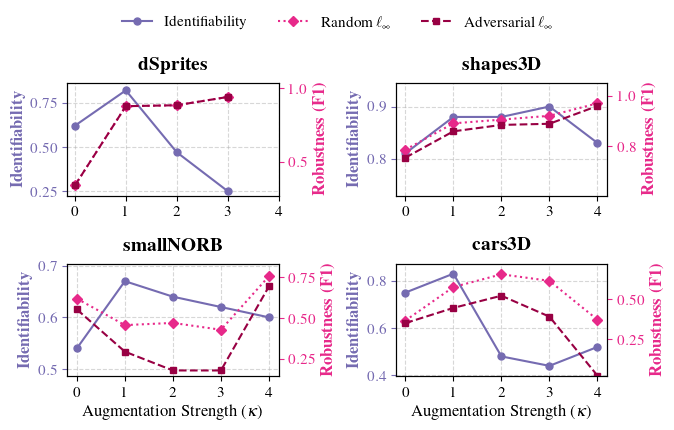

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- ICML Paper Formatting ---
plt.rcParams.update({
    "text.usetex": True,           # Enables true LaTeX rendering for math symbols like \kappa
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,               # Increased base font size
    "axes.titlesize": 14,          # Increased subplot title size
    "axes.labelsize": 12,          # Increased x/y axis label size
    "xtick.labelsize": 11,         # Increased tick label size
    "ytick.labelsize": 11,         # Increased tick label size
    "legend.fontsize": 11,         # Increased legend font size
    "figure.figsize": (6.75, 4.0), # Slightly increased height to accommodate larger fonts
    "pdf.fonttype": 42,            # Ensures fonts are embedded for conference submission
    "ps.fonttype": 42,
    "lines.linewidth": 1.5,        
    "lines.markersize": 5
})

# Data extracted from previous tables
data = {
    'dSprites': {
        'k': np.array([0, 1, 2, 3]),
        'ident': np.array([0.62, 0.82, 0.47, 0.25]),
        'clean': np.array([0.34, 0.93, 0.92, 0.96]),
        'noisy': np.array([0.34, 0.83, 0.85, 0.92]),
        'adv':   np.array([0.34, 0.83, 0.85, 0.92])
    },
    'shapes3D': {
        'k': np.array([0, 1, 2, 3, 4]),
        'ident': np.array([0.81, 0.88, 0.88, 0.90, 0.83]),
        'clean': np.array([0.79, 0.90, 0.92, 0.93, 0.99]),
        'noisy': np.array([0.78, 0.88, 0.89, 0.91, 0.95]),
        'adv':   np.array([0.72, 0.82, 0.85, 0.85, 0.93])
    },
    'smallNORB': {
        'k': np.array([0, 1, 2, 3, 4]),
        'ident': np.array([0.54, 0.67, 0.64, 0.62, 0.60]),
        'clean': np.array([0.62, 0.80, 0.82, 0.82, 0.89]),
        'noisy': np.array([0.62, 0.32, 0.33, 0.29, 0.66]),
        'adv':   np.array([0.50, 0.18, 0.10, 0.10, 0.57])
    },
    'cars3D': {
        'k': np.array([0, 1, 2, 3, 4]),
        'ident': np.array([0.75, 0.83, 0.48, 0.44, 0.52]),
        'clean': np.array([0.37, 0.58, 0.66, 0.64, 0.59]),
        'noisy': np.array([0.36, 0.57, 0.65, 0.59, 0.27]),
        'adv':   np.array([0.33, 0.36, 0.43, 0.28, 0.01])
    }
}

# Helper function to compute F1 score safely
def compute_f1(clean, target):
    f1 = np.zeros_like(clean)
    mask = (clean + target) > 0
    f1[mask] = 2 * (clean[mask] * target[mask]) / (clean[mask] + target[mask])
    return f1

# Styling settings
COLOR_IDENT = '#756bb1' # Purple
COLOR_NOISY = '#e7298a' # Pink/Magenta
COLOR_ADV   = '#980043' # Darker Burgundy/Magenta

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

for idx, (dataset, d) in enumerate(data.items()):
    ax1 = axes[idx]
    ax2 = ax1.twinx()
    
    k = d['k']
    
    # Compute F1 scores
    f1_noisy = compute_f1(d['clean'], d['noisy'])
    f1_adv = compute_f1(d['clean'], d['adv'])
    
    # Plot Identifiability on left y-axis
    l1 = ax1.plot(k, d['ident'], color=COLOR_IDENT, marker='o', linestyle='-', 
                  label='Identifiability')
    
    # Plot F1 Robustness on right y-axis
    l2 = ax2.plot(k, f1_noisy, color=COLOR_NOISY, marker='D', linestyle=':', 
                  label=r'Random $\ell_\infty$')
    l3 = ax2.plot(k, f1_adv, color=COLOR_ADV, marker='s', linestyle='--', 
                  label=r'Adversarial $\ell_\infty$')
    
    # Axis labels and titles
    ax1.set_title(r'\textbf{' + dataset + '}', pad=10)
    
    # Only label x-axis on bottom row to save space
    if idx >= 2:
        ax1.set_xlabel(r'Augmentation Strength ($\kappa$)')
        
    ax1.set_ylabel(r'\textbf{Identifiability}', color=COLOR_IDENT)
    ax2.set_ylabel(r'\textbf{Robustness (F1)}', color=COLOR_NOISY)
    
    # Ticks formatting
    ax1.set_xticks(np.arange(5))
    ax1.tick_params(axis='y', colors=COLOR_IDENT)
    ax2.tick_params(axis='y', colors=COLOR_NOISY)
    
    # Grid formatting
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # Dynamically pad the limits slightly so markers don't get cut off
    ax1.set_ylim(max(0, d['ident'].min() * 0.9), min(1.05, d['ident'].max() * 1.05))
    
    # Set right y-axis bounds to fit both Noisy and Adv data
    min_f1 = min(f1_noisy.min(), f1_adv.min())
    max_f1 = max(f1_noisy.max(), f1_adv.max())
    ax2.set_ylim(max(0, min_f1 * 0.8), min(1.05, max_f1 * 1.1))

# Create a single unified legend at the very top
lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.09), 
           ncol=3, frameon=False)

plt.tight_layout()

# Save as a print-ready vector PDF for ICML
plt.savefig('robustness_f1_icml_rebuttal.pdf', bbox_inches='tight', format='pdf')
plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\%'
<>:31: SyntaxWarning: invalid escape sequence '\%'
<>:30: SyntaxWarning: invalid escape sequence '\%'
<>:31: SyntaxWarning: invalid escape sequence '\%'
/var/folders/cr/qd8xdw991dv9ypjzzwsktpqc0000gn/T/ipykernel_47094/3178219943.py:30: SyntaxWarning: invalid escape sequence '\%'
  id_labels = [f"{v:.1f}\%" for v in id_loss_data]
/var/folders/cr/qd8xdw991dv9ypjzzwsktpqc0000gn/T/ipykernel_47094/3178219943.py:31: SyntaxWarning: invalid escape sequence '\%'
  f1_labels = [f"{v:.1f}\%" for v in f1_loss_data]


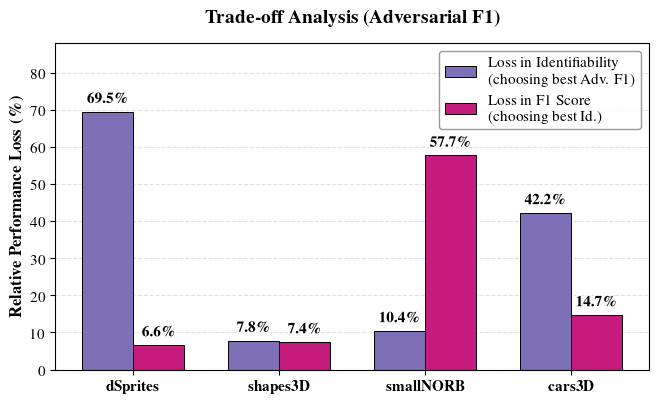

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as path_effects

# --- ICML Legibility and Tex support settings ---
plt.rcParams.update({
    "text.usetex": True,           
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,               
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.figsize": (6.75, 4.2), 
    "pdf.fonttype": 42,            
    "ps.fonttype": 42,
    "lines.linewidth": 1.5,
    "lines.markersize": 5
})

# --- Updated Data Points ---
datasets = ["dSprites", "shapes3D", "smallNORB", "cars3D"]

id_loss_data = np.array([69.5, 7.8, 10.4, 42.2])
f1_loss_data = np.array([6.6, 7.4, 57.7, 14.7]) 

# Rounded labels for display above bars
id_labels = [f"{v:.1f}\%" for v in id_loss_data]
f1_labels = [f"{v:.1f}\%" for v in f1_loss_data]

x_indexes = np.arange(len(datasets))
bar_width = 0.35

# Color Palettes 
color_purple_deep = '#7c6fb6'
color_pink_deep   = '#c51b7d'

fig, ax = plt.subplots()

# Create the grouped bars
rects1 = ax.bar(x_indexes - bar_width/2, id_loss_data, bar_width, 
                label='Loss in Identifiability\n(choosing best Adv. F1)', 
                color=color_purple_deep, edgecolor='black', linewidth=0.7)
rects2 = ax.bar(x_indexes + bar_width/2, f1_loss_data, bar_width, 
                label='Loss in F1 Score\n(choosing best Id.)', 
                color=color_pink_deep, edgecolor='black', linewidth=0.7)

# --- Formatting ---

# X/Y axis labels and title
ax.set_ylabel(r'\textbf{Relative Performance Loss (\%)}')
ax.set_title(r'\textbf{Trade-off Analysis (Adversarial F1)}', pad=15)

# X-axis ticks 
ax.set_xticks(x_indexes)
ax.set_xticklabels([r'\textbf{' + ds + '}' for ds in datasets])

# Add light dashed gridlines on the y-axis for readability
ax.grid(axis='y', linestyle='--', color='lightgrey', alpha=0.7)
ax.set_axisbelow(True) # Ensure grid is behind the bars

# Y-axis bounds (increased to 88 to guarantee room for the legend in the top right)
ax.set_ylim(0, 88) 

# Helper function to attach a highly readable text label above each bar
def autolabel(rects, labels_list):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for i, rect in enumerate(rects):
        height = rect.get_height()
        
        # Make the text bold for better readability
        text = ax.annotate(r'\textbf{' + labels_list[i] + '}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)
        
        # Add a white stroke/outline to the text so it cuts through gridlines cleanly
        text.set_path_effects([path_effects.withStroke(linewidth=2.5, foreground='white')])

# Attach the rounded labels
autolabel(rects1, id_labels)
autolabel(rects2, f1_labels)

# Force legend into the empty space in the upper right
ax.legend(loc='upper right', frameon=True, edgecolor='grey')

plt.tight_layout()

# Save figure in print-ready vector format
plt.savefig('tradeoff_adversarial_f1_rebuttal.pdf', bbox_inches='tight', format='pdf')
plt.show()